# Phase 4 — MLP on Morgan FP

PyTorch feed-forward MLP on the **same Morgan FP** (radius=2, 2048 bits) used in Phase 1, with **no descriptors**. Same evaluation protocol as Phases 1–3 (random + balanced scaffold 5-seed).

**Why this phase exists.** Between Phase 3 (tuned XGBoost on Morgan + descriptors) and Phase 5 (ChemProp on molecular graphs), two things change at once: the model class *and* the representation. Phase 4 isolates one axis: changing only the **model** while keeping Phase 1's featurization. This produces a clean attribution:

- Phase 1 (RF on Morgan) → Phase 4 (MLP on Morgan): expressivity contribution.
- Phase 4 (MLP on Morgan) → Phase 5 (ChemProp): representation contribution.

It also doubles as the **PyTorch infrastructure validation** for Phase 5 and downstream projects (ADMET, virtual screening on ChEMBL).

**Pre-registered expectations.** RMSE somewhere between Phase 1 (1.591) and Phase 2 (1.062). If the MLP without descriptors significantly beats RF without descriptors, part of Phase 1's error budget was about model expressivity, not features. If it doesn't, it was features all along.

**Pre-registered decision rule for Phase 5 framing**, conditional on the hydrophilic mean residual at the end of this notebook:

| Phase 4 hydrophilic mean_resid | Reading | Implication for Phase 5 |
|---|---|---|
| ≈ −0.4 (like Phase 3) | Bias is feature-bound, not model-bound | Strong ChemProp case: graph is the only remaining lever |
| ≈ −0.2 | Model contributes but doesn't resolve | ChemProp expected at ≈ −0.1, marginal but justified |
| ≈ −0.1 or better | Surprise: model alone was enough | Phase 5 still worth doing, but with cautious priors |


## 1. Setup

In [2]:
import os
import sys
from pathlib import Path

# Detect runtime environment
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/qsar-esol-solubility')
else:
    PROJECT_ROOT = Path.cwd().parent

DATA_DIR      = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'models'
REPORTS_DIR   = PROJECT_ROOT / 'reports'
FIGURES_DIR   = REPORTS_DIR / 'figures'
for d in [PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Make src/ importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")


Mounted at /content/drive
Environment: Colab
Project root: /content/drive/MyDrive/qsar-esol-solubility


In [3]:
# Install only what's missing in Colab. RDKit + Optuna already in requirements.
if IN_COLAB:
    !pip install rdkit optuna -q

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import optuna

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

# Project package
from src.featurization import featurize_morgan, fit_median_imputer, apply_imputer
from src.splits import scaffold_split_balanced, scaffold_kfold
from src.metrics import evaluate, aggregate_seed_runs
from src.reporting import save_summary_json, load_summary_json, paired_delta
from src.training import (
    train_mlp,
    tune_mlp_optuna,
    evaluate_5seed_scaffold,
    MLPSearchSpace,
    seed_everything,
)

RANDOM_SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__}   |   Optuna: {optuna.__version__}   |   Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.2 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128   |   Optuna: 4.8.0   |   Device: cuda
GPU: Tesla T4


## 2. Load deduplicated dataset

Same `data/processed/esol_dedup.csv` produced by notebook 01 (1117 molecules). Mol objects rebuilt on the fly.


In [4]:
df = pd.read_csv(PROCESSED_DIR / 'esol_dedup.csv')
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
n_failed = df['mol'].isna().sum()
assert n_failed == 0, f"{n_failed} SMILES failed to parse"
print(f"Loaded {len(df)} molecules.   Columns: {list(df.columns)}")
print(f"logS range: [{df['logS'].min():.2f}, {df['logS'].max():.2f}]   "
      f"mean={df['logS'].mean():.2f}   std={df['logS'].std():.2f}")


Loaded 1117 molecules.   Columns: ['smiles', 'logS', 'mol']
logS range: [-11.60, 1.58]   mean=-3.05   std=2.10


## 3. Sanity check — single MLP, no tuning

Train one MLP with **reasonable defaults** on the seed=42 balanced scaffold split, no Optuna. Goal: validate the training loop end-to-end before committing 100 Optuna trials × 5 CV folds of compute.

**Acceptance criteria:**
- Valid RMSE in **[1.3, 1.6]** range — between Phase 1 RF on Morgan (1.591 ± 0.126) and Phase 2 RF on Morgan+desc (1.062 ± 0.053). If valid RMSE > 1.8 → likely a bug (target standardization, leakage, BN with batch_size=1, …). If valid RMSE < 1.0 already without descriptors and without tuning → likely a leak.
- Loss decreases monotonically over the first ~30 epochs (with Adam noise).
- Early stopping triggers (i.e. training does not exhaust max_epochs without improving).


In [5]:
# Outer split (seed=42, balanced scaffold)
tr_idx, va_idx, te_idx = scaffold_split_balanced(df, seed=RANDOM_SEED)
df_tr = df.loc[tr_idx].reset_index(drop=True)
df_va = df.loc[va_idx].reset_index(drop=True)
df_te = df.loc[te_idx].reset_index(drop=True)
print(f"Split sizes: train={len(df_tr)}  valid={len(df_va)}  test={len(df_te)}")

# Featurize (Morgan FP only, NO descriptors → isolates the model axis)
X_tr_raw = featurize_morgan(df_tr).astype(np.float32)
X_va_raw = featurize_morgan(df_va).astype(np.float32)
X_te_raw = featurize_morgan(df_te).astype(np.float32)
y_tr = df_tr['logS'].values.astype(np.float64)
y_va = df_va['logS'].values.astype(np.float64)
y_te = df_te['logS'].values.astype(np.float64)

# Median imputation (no-op on Morgan binary FPs but pattern kept for portability)
medians, keep = fit_median_imputer(X_tr_raw)
X_tr = apply_imputer(X_tr_raw, medians, keep)
X_va = apply_imputer(X_va_raw, medians, keep)
X_te = apply_imputer(X_te_raw, medians, keep)
print(f"Feature shape: {X_tr.shape}   |   columns kept: {keep.sum()}/{len(keep)}")


Split sizes: train=893  valid=111  test=113
Feature shape: (893, 2048)   |   columns kept: 2048/2048


In [6]:
# Reasonable default config — NOT tuned. Goal here is loop validation only.
DEFAULT_CONFIG = dict(
    hidden_dims=(512, 256),
    dropout=0.3,
    use_batchnorm=True,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=64,
    max_epochs=200,
    patience=20,
    device=DEVICE,
    seed=RANDOM_SEED,
    verbose=True,
)

t0 = time.time()
sanity = train_mlp(X_tr, y_tr, X_va, y_va, **DEFAULT_CONFIG)
elapsed = time.time() - t0

y_pred_va = sanity['predict'](X_va)
y_pred_te = sanity['predict'](X_te)
metrics_sanity = {
    'valid': evaluate(y_va, y_pred_va, 'valid', include_arrays=False),
    'test':  evaluate(y_te, y_pred_te, 'test',  include_arrays=False),
}
print(f"\nSanity training time: {elapsed:.1f}s   |   stopped at epoch {sanity['stopped_at']}, best at {sanity['best_epoch']}")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print('-' * 32)
for name, m in metrics_sanity.items():
    print(f"{name:<8} {m['RMSE']:>7.3f} {m['MAE']:>7.3f} {m['R2']:>7.3f}")

valid_rmse = metrics_sanity['valid']['RMSE']
if valid_rmse > 1.8:
    print('\n⚠️  Valid RMSE > 1.8 — likely a bug. Check standardization, leakage, BN with tiny batches.')
elif valid_rmse < 1.0:
    print('\n⚠️  Valid RMSE < 1.0 without tuning AND without descriptors — surprising. Double-check the split for leakage.')
else:
    print('\n✅ Valid RMSE in expected range [1.0, 1.8]. Training loop is sane.')


  epoch   1 | train_loss=0.7273  valid_rmse=2.2498  lr=1.00e-03
  epoch  20 | train_loss=0.0917  valid_rmse=1.4530  lr=1.00e-03
  epoch  40 | train_loss=0.0532  valid_rmse=1.4776  lr=5.00e-04
  early stop at epoch 45 (best valid_rmse=1.4029 @ epoch 25)

Sanity training time: 9.7s   |   stopped at epoch 45, best at 25
Split       RMSE     MAE      R²
--------------------------------
valid      1.403   1.077   0.575
test       1.546   1.204   0.336

✅ Valid RMSE in expected range [1.0, 1.8]. Training loop is sane.


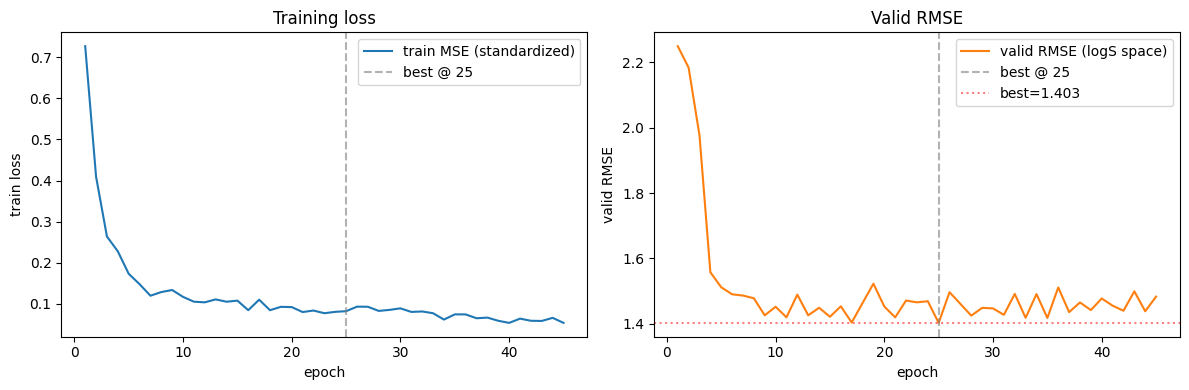

In [7]:
# Diagnostic: training history. Should show monotone decrease + early stopping.
hist = pd.DataFrame(sanity['history'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist['epoch'], hist['train_loss'], label='train MSE (standardized)', color='tab:blue')
ax1.set_xlabel('epoch'); ax1.set_ylabel('train loss')
ax1.set_title('Training loss')
ax1.axvline(sanity['best_epoch'], color='gray', ls='--', alpha=0.6, label=f"best @ {sanity['best_epoch']}")
ax1.legend()

ax2.plot(hist['epoch'], hist['valid_rmse'], color='tab:orange', label='valid RMSE (logS space)')
ax2.axvline(sanity['best_epoch'], color='gray', ls='--', alpha=0.6, label=f"best @ {sanity['best_epoch']}")
ax2.axhline(sanity['best_valid_rmse'], color='red', ls=':', alpha=0.5,
            label=f"best={sanity['best_valid_rmse']:.3f}")
ax2.set_xlabel('epoch'); ax2.set_ylabel('valid RMSE')
ax2.set_title('Valid RMSE')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase4_sanity_history.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Optuna tuning (100 trials, scaffold-aware 5-fold CV)

Same protocol as Phase 3 for symmetry:
- Tuning on **scaffold-disjoint 5-fold CV** inside `df_tr` (seed=42 outer split). The valid/test of the outer split are never seen during tuning.
- 100 trials, TPE sampler, MedianPruner.
- Search space:  
    `n_hidden_layers ∈ {1,2,3}`, `hidden_dim_1 ∈ {128,256,512,1024}`, `dropout ∈ [0,0.5]`,  
    `lr ∈ [1e-5, 1e-2]` log, `weight_decay ∈ [1e-7, 1e-3]` log,  
    `batch_size ∈ {32,64,128,256}`, `use_batchnorm ∈ {True,False}`.
- Best params selected once on seed=42, **re-fitted (not re-tuned) on the 5 outer scaffold seeds** in §6.


In [8]:
# Build scaffold-aware inner CV folds inside df_tr (positional indices 0..len(df_tr)-1).
cv_splits = scaffold_kfold(df_tr, n_folds=5, seed=RANDOM_SEED)
for k, (tr, va) in enumerate(cv_splits):
    print(f"Inner CV fold {k}: train={len(tr)}  valid={len(va)}")


Inner CV fold 0: train=577  valid=316
Inner CV fold 1: train=640  valid=253
Inner CV fold 2: train=785  valid=108
Inner CV fold 3: train=785  valid=108
Inner CV fold 4: train=785  valid=108


In [9]:
# Reduce Optuna verbosity to a manageable level
optuna.logging.set_verbosity(optuna.logging.WARNING)

# A short epoch budget per CV fold during tuning keeps the study within ~one
# evening of compute. Final 5-seed eval in §6 uses max_epochs=200, patience=20.
TUNING_MAX_EPOCHS = 100
TUNING_PATIENCE   = 15

t0 = time.time()
study, best_params = tune_mlp_optuna(
    df_train_full=df_tr,
    featurize_fn=lambda d: featurize_morgan(d).astype(np.float32),
    target_col='logS',
    cv_splits=cv_splits,
    n_trials=100,
    space=MLPSearchSpace(),
    impute=True,
    max_epochs=TUNING_MAX_EPOCHS,
    patience=TUNING_PATIENCE,
    device=DEVICE,
    seed=RANDOM_SEED,
    show_progress=True,
)
tuning_time = time.time() - t0
print(f"\nTuning time: {tuning_time/60:.1f} min   |   trials run: {len(study.trials)}")
print(f"Best CV-RMSE: {study.best_value:.4f}")
print(f"Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/100 [00:00<?, ?it/s]


Tuning time: 7.2 min   |   trials run: 100
Best CV-RMSE: 1.6176
Best params:
  hidden_dims: (512, 256)
  dropout: 0.32036917602523796
  lr: 0.0030215644709678984
  weight_decay: 2.3125519393338786e-05
  batch_size: 32
  use_batchnorm: True


## 5. FANOVA hyperparameter importance

Same diagnostic as Phase 3. Quantifies how much each hyperparameter contributes to the variance of CV-RMSE across the 100 trials. Useful as a **prior for ADMET**: which knobs deserve a bigger Optuna budget on a different but related dataset.


          param  importance
  use_batchnorm       0.729
             lr       0.121
n_hidden_layers       0.041
   weight_decay       0.035
   hidden_dim_1       0.034
        dropout       0.023
     batch_size       0.017


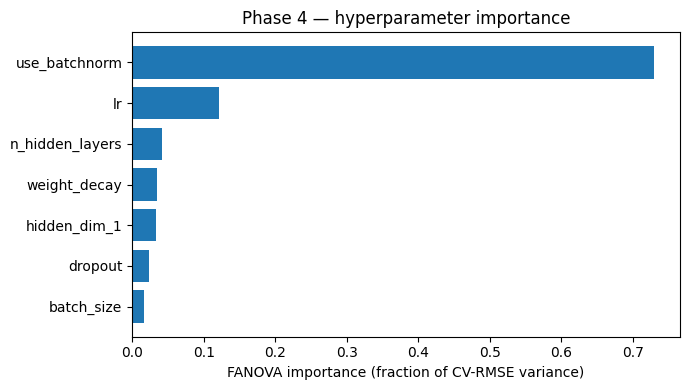

In [10]:
from optuna.importance import get_param_importances

try:
    importances = get_param_importances(study)
    imp_df = pd.DataFrame(
        sorted(importances.items(), key=lambda kv: kv[1], reverse=True),
        columns=['param', 'importance'],
    )
    print(imp_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(imp_df['param'][::-1], imp_df['importance'][::-1])
    ax.set_xlabel('FANOVA importance (fraction of CV-RMSE variance)')
    ax.set_title('Phase 4 — hyperparameter importance')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'phase4_fanova.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"FANOVA failed: {e}. Continuing without importance plot.")
    importances = {}


## 6. 5-seed scaffold evaluation with best params

Re-fit the best Optuna config on the **5 outer scaffold seeds** `[42, 0, 1, 2, 3]`. Tests **generalization of the chosen hyperparameters**, not their tunability — exactly the same pattern as Phase 3.

Final epoch budget is increased back to 200 / patience 20.


In [11]:
# Wrap train_mlp so its signature matches what evaluate_5seed_scaffold expects:
# (X_tr, y_tr, X_va, y_va, seed=...) -> dict with 'predict'.
def train_mlp_with_best(X_tr, y_tr, X_va, y_va, seed):
    return train_mlp(
        X_tr, y_tr, X_va, y_va,
        hidden_dims=best_params['hidden_dims'],
        dropout=best_params['dropout'],
        use_batchnorm=best_params['use_batchnorm'],
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        batch_size=best_params['batch_size'],
        max_epochs=200,
        patience=20,
        device=DEVICE,
        seed=seed,
        verbose=False,
    )

t0 = time.time()
result_5seed = evaluate_5seed_scaffold(
    df=df,
    target_col='logS',
    featurize_fn=lambda d: featurize_morgan(d).astype(np.float32),
    train_fn=train_mlp_with_best,
    train_kwargs={},  # train_mlp_with_best closes over best_params
    seeds=(42, 0, 1, 2, 3),
    impute=True,
    smiles_col='smiles',
    verbose=True,
)
fivessed_time = time.time() - t0
print(f"\n5-seed eval time: {fivessed_time/60:.1f} min")


Seed 42: test RMSE=1.399  MAE=1.108  R²=+0.456  (n_test=113)
Seed  0: test RMSE=1.293  MAE=1.007  R²=+0.543  (n_test=113)
Seed  1: test RMSE=1.445  MAE=1.149  R²=+0.411  (n_test=113)
Seed  2: test RMSE=1.609  MAE=1.268  R²=+0.438  (n_test=113)
Seed  3: test RMSE=1.433  MAE=1.133  R²=+0.482  (n_test=113)

Aggregate over 5 seeds:
  RMSE = 1.436 ± 0.102
  MAE  = 1.133 ± 0.084
  R²   = +0.466 ± 0.045

5-seed eval time: 0.2 min


## 7. Persistence — JSON summary + best params

Write `models/mlp_esol_phase4_best_params.json` and `reports/phase4_summary.json` for downstream Phase 5 paired-delta computation.


In [12]:
# Save best params (JSON-friendly: tuples → lists)
best_params_serialisable = {
    k: (list(v) if isinstance(v, tuple) else v)
    for k, v in best_params.items()
}
params_path = MODELS_DIR / 'mlp_esol_phase4_best_params.json'
with open(params_path, 'w') as f:
    json.dump(
        {
            'best_params': best_params_serialisable,
            'cv_best_value': float(study.best_value),
            'n_trials': len(study.trials),
            'tuning_max_epochs': TUNING_MAX_EPOCHS,
            'tuning_patience': TUNING_PATIENCE,
            'fanova_importances': {k: float(v) for k, v in importances.items()},
        },
        f, indent=2,
    )
print(f"Saved best params: {params_path}")

# Save phase summary (5-seed metrics, no per-seed array bloat)
summary_path = save_summary_json(
    REPORTS_DIR / 'phase4_summary.json',
    phase='phase4_mlp_morgan',
    per_seed=result_5seed['per_seed'],
    aggregate=result_5seed['aggregate'],
    best_params=best_params_serialisable,
    extra={
        'featurization': 'morgan_fp_2048_radius2',
        'descriptors_used': False,
        'tuning_protocol': 'scaffold_kfold_5_seed42',
        'final_max_epochs': 200,
        'final_patience': 20,
        'cv_best_value': float(study.best_value),
        'n_trials': len(study.trials),
        'tuning_time_min': round(tuning_time / 60, 2),
        'fivessed_time_min': round(fivessed_time / 60, 2),
    },
)
print(f"Saved phase summary: {summary_path}")


Saved best params: /content/drive/MyDrive/qsar-esol-solubility/models/mlp_esol_phase4_best_params.json
Saved phase summary: /content/drive/MyDrive/qsar-esol-solubility/reports/phase4_summary.json


## 8. Comparison with Phase 1 (paired delta, same seeds)

Phase 1 (RF on Morgan FP, no descriptors) is the only fair like-for-like comparison: **same featurization, different model class**. Phase 2 and Phase 3 used Morgan + descriptors, which is a different question.

If `phase1_summary.json` exists, compute paired delta. Otherwise fall back to literature numbers (Phase 1 RMSE 1.591 ± 0.126).


In [13]:
phase1_summary_path = REPORTS_DIR / 'phase1_summary.json'
if phase1_summary_path.exists():
    p1 = load_summary_json(phase1_summary_path)
    delta_rmse = paired_delta(p1['per_seed'], result_5seed['per_seed'], metric='RMSE')
    delta_r2   = paired_delta(p1['per_seed'], result_5seed['per_seed'], metric='R2')
    print('Paired delta Phase 1 → Phase 4 (per seed):')
    for d in delta_rmse['per_seed_delta']:
        print(f"  seed {d['seed']:>2}: ΔRMSE = {d['delta']:+.3f}")
    print(f"\nMean ΔRMSE = {delta_rmse['mean_delta']:+.3f} ± {delta_rmse['std_delta']:.3f}   "
          f"(wins {delta_rmse['wins']}/{delta_rmse['n_seeds']})")
    print(f"Mean ΔR²   = {delta_r2['mean_delta']:+.3f} ± {delta_r2['std_delta']:.3f}   "
          f"(wins {delta_r2['wins']}/{delta_r2['n_seeds']})")
else:
    print(f"(phase1_summary.json not found — falling back to README numbers)")
    print(f"Phase 1 (RF on Morgan, 5-seed scaffold): RMSE 1.591 ± 0.126,  R² 0.344 ± 0.066")
    p4 = result_5seed['aggregate']
    print(f"Phase 4 (MLP on Morgan, 5-seed scaffold): "
          f"RMSE {p4['RMSE_mean']:.3f} ± {p4['RMSE_std']:.3f},  "
          f"R² {p4['R2_mean']:.3f} ± {p4['R2_std']:.3f}")
    print(f"\nNote: without per-seed Phase 1 JSON, this is an unpaired comparison — the "
          f"per-seed delta would be tighter than the difference of means suggests.")


(phase1_summary.json not found — falling back to README numbers)
Phase 1 (RF on Morgan, 5-seed scaffold): RMSE 1.591 ± 0.126,  R² 0.344 ± 0.066
Phase 4 (MLP on Morgan, 5-seed scaffold): RMSE 1.436 ± 0.102,  R² 0.466 ± 0.045

Note: without per-seed Phase 1 JSON, this is an unpaired comparison — the per-seed delta would be tighter than the difference of means suggests.


## 9. Stratified analysis — the **point of this notebook**

Aggregate RMSE alone tells us if the model class moves the average. To decide what Phase 5 should aim for, we need to know **where** the error lives — specifically the hydrophilic mean residual, which was −0.9 in Phase 2 and −0.45 in Phase 3 (the sugar bias).

Pool predictions across the 5 seeds and stratify by logS regime:
- **hydrophilic**: logS > −2
- **moderate**:   −5 ≤ logS ≤ −2
- **hydrophobic**: logS < −5

Reported per regime: count, mean residual (`y_pred - y_true`, sign-aware), MAE, RMSE.


In [14]:
# Pool predictions across all 5 seeds
all_y_true, all_y_pred, all_smiles, all_seeds_col = [], [], [], []
for r in result_5seed['per_seed']:
    all_y_true.append(r['y_true'])
    all_y_pred.append(r['y_pred'])
    if r['test_smiles'] is not None:
        all_smiles.extend(r['test_smiles'])
    else:
        all_smiles.extend([None] * len(r['y_true']))
    all_seeds_col.extend([r['seed']] * len(r['y_true']))

y_true_pool = np.concatenate(all_y_true)
y_pred_pool = np.concatenate(all_y_pred)
residuals   = y_pred_pool - y_true_pool   # positive = over-prediction of solubility

pool = pd.DataFrame({
    'seed':     all_seeds_col,
    'smiles':   all_smiles,
    'y_true':   y_true_pool,
    'y_pred':   y_pred_pool,
    'residual': residuals,
})

def regime_of(logS):
    if logS > -2:   return 'hydrophilic'
    if logS < -5:   return 'hydrophobic'
    return 'moderate'

pool['regime'] = pool['y_true'].apply(regime_of)

regime_stats = pool.groupby('regime').agg(
    n=('y_true', 'size'),
    mean_resid=('residual', 'mean'),
    MAE=('residual', lambda r: np.mean(np.abs(r))),
    RMSE=('residual', lambda r: np.sqrt(np.mean(r ** 2))),
).loc[['hydrophilic', 'moderate', 'hydrophobic']]

print('Phase 4 — stratified test-set performance (pooled across 5 seeds):')
print(regime_stats.to_string(float_format=lambda x: f"{x:+.3f}"))


Phase 4 — stratified test-set performance (pooled across 5 seeds):
               n  mean_resid    MAE   RMSE
regime                                    
hydrophilic  104      -0.674 +1.050 +1.298
moderate     335      +0.552 +0.885 +1.144
hydrophobic  126      +1.813 +1.859 +2.103


In [15]:
# Decision rule — print which Phase 5 framing the result triggers
hydro_resid = regime_stats.loc['hydrophilic', 'mean_resid']
print(f"\nHydrophilic mean residual (Phase 4): {hydro_resid:+.3f}")
print(f"Reference points:")
print(f"  Phase 2 (RF on Morgan+desc):   ≈ −0.90")
print(f"  Phase 3 (XGBoost on Morgan+desc): ≈ −0.45")
print()
if hydro_resid <= -0.35:
    print('→ Reading: bias is largely feature-bound. ChemProp case is STRONG '
          '(graph is the only remaining lever).')
elif hydro_resid <= -0.15:
    print('→ Reading: model contributes meaningfully but does not resolve. '
          'ChemProp expected to bring residual to ≈ −0.10, MARGINAL but justified.')
else:
    print('→ Reading: the model alone closed most of the gap. ChemProp still worth '
          'doing for representation quality, but with CAUTIOUS priors on Δ.')



Hydrophilic mean residual (Phase 4): -0.674
Reference points:
  Phase 2 (RF on Morgan+desc):   ≈ −0.90
  Phase 3 (XGBoost on Morgan+desc): ≈ −0.45

→ Reading: bias is largely feature-bound. ChemProp case is STRONG (graph is the only remaining lever).


## 10. Top-N worst residuals

Look at the 10 worst over- and under-predictions. If sugars dominate the under-prediction list (as in Phase 2 and partially Phase 3), the failure mode survived the model change and the case for representation-side improvement (Phase 5) is sharpened.


In [19]:
# Drop seed-duplicate predictions on the same SMILES by keeping the worst residual.
# (Different seeds produce different test sets, but a given SMILES may appear in
# more than one — keeping the worst per molecule highlights persistent failures.)
agg_by_smiles = pool.dropna(subset=['smiles']).copy()
agg_by_smiles['abs_residual'] = agg_by_smiles['residual'].abs()
worst = (
    agg_by_smiles.sort_values('abs_residual', ascending=False)
    .drop_duplicates('smiles')
    .head(10)
    [['smiles', 'y_true', 'y_pred', 'residual', 'regime', 'seed']]
    .reset_index(drop=True)
)
print('Top 10 worst residuals (Phase 4):')
print(worst.to_string(float_format=lambda x: f"{x:+.3f}"))


Top 10 worst residuals (Phase 4):
                                                             smiles  y_true  y_pred  residual       regime  seed
0                            c1cc2ccc3ccc4ccc5ccc6ccc1c1c2c3c4c5c61  -9.332  -4.242    +5.090  hydrophobic     2
1  ClC1(Cl)C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(Cl)C5(Cl)C24Cl  -6.800  -2.237    +4.563  hydrophobic     3
2                        CCOc1ccc(C(C)(C)COCc2cccc(Oc3ccccc3)c2)cc1  -8.600  -4.358    +4.242  hydrophobic     2
3               CC1COC2CC3(C)C(CC4C5C=C6CC(O)CCC6(C)CC5CCC43C)OC2C1  -7.320  -3.852    +3.468  hydrophobic     2
4                         CN1C(C(=O)Nc2ccccn2)=C(O)c2ccccc2S1(=O)=O  -4.160  -0.738    +3.422     moderate     1
5                                                     O=C1CCC(=O)N1  +0.300  -3.080    -3.380  hydrophilic     0
6                                c1ccc2cc3c(cc2c1)-c1cccc2cccc-3c12  -8.490  -5.113    +3.377  hydrophobic     2
7                              c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3

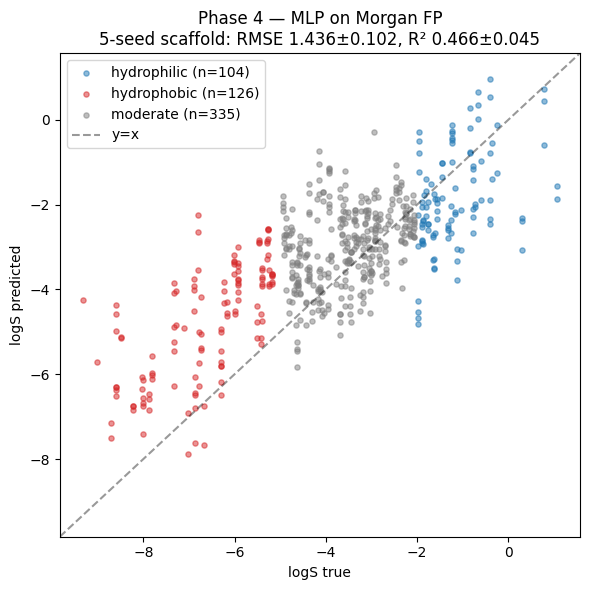

In [17]:
# Parity plot, colored by regime
fig, ax = plt.subplots(figsize=(6, 6))
colors = {'hydrophilic': 'tab:blue', 'moderate': 'tab:gray', 'hydrophobic': 'tab:red'}
for regime, sub in pool.groupby('regime'):
    ax.scatter(sub['y_true'], sub['y_pred'], s=14, alpha=0.5,
               c=colors[regime], label=f"{regime} (n={len(sub)})")
lims = [pool['y_true'].min() - 0.5, pool['y_true'].max() + 0.5]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('logS true'); ax.set_ylabel('logS predicted')
p4 = result_5seed['aggregate']
ax.set_title(
    f"Phase 4 — MLP on Morgan FP\n"
    f"5-seed scaffold: RMSE {p4['RMSE_mean']:.3f}±{p4['RMSE_std']:.3f}, "
    f"R² {p4['R2_mean']:.3f}±{p4['R2_std']:.3f}"
)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase4_parity.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Update README — final numbers

Print the values to paste into the README status table and into the project context document.


In [20]:
p4 = result_5seed['aggregate']
print('=' * 70)
print('Phase 4 — MLP on Morgan FP — final numbers')
print('=' * 70)
print(f"5-seed scaffold balanced:")
print(f"  RMSE = {p4['RMSE_mean']:.3f} ± {p4['RMSE_std']:.3f}")
print(f"  MAE  = {p4['MAE_mean']:.3f} ± {p4['MAE_std']:.3f}")
print(f"  R²   = {p4['R2_mean']:+.3f} ± {p4['R2_std']:.3f}")
print()
print('README row to paste:')
print(
    f"| 4   | Morgan FP                                | MLP (PyTorch tuned)  "
    f"| **{p4['RMSE_mean']:.3f} ± {p4['RMSE_std']:.3f}** "
    f"| **{p4['R2_mean']:.3f} ± {p4['R2_std']:.3f}** | ✅ done |"
)
print()
print('Per-regime mean residuals:')
for regime in ['hydrophilic', 'moderate', 'hydrophobic']:
    n = int(regime_stats.loc[regime, 'n'])
    mr = regime_stats.loc[regime, 'mean_resid']
    print(f"  {regime:<11} (n={n:>4}): mean_resid = {mr:+.3f}")


Phase 4 — MLP on Morgan FP — final numbers
5-seed scaffold balanced:
  RMSE = 1.436 ± 0.102
  MAE  = 1.133 ± 0.084
  R²   = +0.466 ± 0.045

README row to paste:
| 4   | Morgan FP                                | MLP (PyTorch tuned)  | **1.436 ± 0.102** | **0.466 ± 0.045** | ✅ done |

Per-regime mean residuals:
  hydrophilic (n= 104): mean_resid = -0.674
  moderate    (n= 335): mean_resid = +0.552
  hydrophobic (n= 126): mean_resid = +1.813


In [21]:
# Sugar/polyol diagnostic: identify polyhydroxylated molecules and check
# whether the sugar bias of Phase 2/3 is improved or just hidden behind
# larger residuals from PAH/halogenated outliers in Phase 4.

from rdkit import Chem

def count_oh(smiles: str) -> int:
    """Count free hydroxyl groups (-OH) via SMARTS, not regex."""
    if smiles is None:
        return 0
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    # SMARTS: oxygen bonded to (exactly 1 heavy atom) and (exactly 1 H)
    pattern = Chem.MolFromSmarts('[OX2H]')
    return len(mol.GetSubstructMatches(pattern))

pool['n_oh'] = pool['smiles'].apply(count_oh)
polyols = pool[pool['n_oh'] >= 3].copy()

print(f"Molecules with ≥3 free –OH (proper polyol screen via RDKit): "
      f"{len(polyols)} of {len(pool)} pooled test predictions")
print(f"  among unique SMILES: {polyols['smiles'].nunique()}")
print()
print(f"Residual statistics on polyols (n={len(polyols)}):")
print(f"  mean residual: {polyols['residual'].mean():+.3f}")
print(f"  median:        {polyols['residual'].median():+.3f}")
print(f"  MAE:           {polyols['residual'].abs().mean():.3f}")
print()
print(f"Reference points:")
print(f"  Phase 2 hydrophilic mean_resid: ≈ -0.90  (sugars dominant in worst-5)")
print(f"  Phase 3 hydrophilic mean_resid: ≈ -0.45  (1 sugar in worst-5)")
print(f"  Phase 4 hydrophilic mean_resid:   -0.674 (0 sugars in worst-10)")
print()
print(f"Top 5 worst polyol residuals in Phase 4:")
print(polyols.nlargest(5, 'residual', keep='first')[
    ['smiles', 'y_true', 'y_pred', 'residual', 'n_oh']
].to_string(index=False))
print()
print(f"Top 5 best (most accurately predicted) polyols:")
print(polyols.iloc[polyols['residual'].abs().argsort()[:5]][
    ['smiles', 'y_true', 'y_pred', 'residual', 'n_oh']
].to_string(index=False))

Molecules with ≥3 free –OH (proper polyol screen via RDKit): 43 of 565 pooled test predictions
  among unique SMILES: 14

Residual statistics on polyols (n=43):
  mean residual: +0.488
  median:        +0.715
  MAE:           0.852

Reference points:
  Phase 2 hydrophilic mean_resid: ≈ -0.90  (sugars dominant in worst-5)
  Phase 3 hydrophilic mean_resid: ≈ -0.45  (1 sugar in worst-5)
  Phase 4 hydrophilic mean_resid:   -0.674 (0 sugars in worst-10)

Top 5 worst polyol residuals in Phase 4:
                                             smiles  y_true    y_pred  residual  n_oh
Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(CC(O)C(O)C(O)CO)c2cc1C  -3.685 -1.640778  2.044222     4
Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(CC(O)C(O)C(O)CO)c2cc1C  -3.685 -1.815553  1.869447     4
                      Nc1ncnc2c1ccn2C1OC(CO)C(O)C1O  -1.950 -0.285438  1.664562     3
             O=C1CC(c2ccc(O)c(O)c2)Oc2cc(O)cc(O)c21  -3.620 -1.999408  1.620592     4
             O=C1CC(c2ccc(O)c(O)c2)Oc2cc(O)cc(O)c21  -3.620 -2.162145  1.45